In [2]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import casadi as ca
from lie.SE23 import *
from flowpipe.inner_bound import *
from flowpipe.outer_bound import *
from flowpipe.flowpipe import *
from sim.multirotor_control import *
from sim.multirotor_plan import *
# from sim.bezier_planning import *

python:  /usr/bin/python3
python:  /usr/bin/python3


In [3]:

# bezier boundary conditions
bc_t = np.array([
            [ # position
            [0,0,0],
            [9.12,-0.46,0],
            [11.16,8.27,0],
            [20.27,8.15,0],
            [19.6,-1.9,0]],
            [ # velocity
            [0.1,-0.1,0],
            [0.1,0.1,0],
            [0.1,0.1,0],
            [-0.1,-0.1,0],
            [0,0,0]],
            [ # accel
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            ],
            [ # jerk
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],  # wp0, x, y, z
            [0, 0, 0],
            ]])
bc_psi_list = np.array(
    [
        [  # attitude
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
        ],
        [  # angular velocity
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
        ],
    ]
)
bc_t = np.array(
    [
        [  # position
            [0, 0, 0],  # wp0, x, y, z
            [0, 0, 2],  # wp0, x, y, z
            [0, -5, 2],
            [5, -5, 1],
            [5, 0, 2],
            [5, 5, 2],
            [0, 5, 1],
            [0, 5, 1],
            [0, 5, 1],
            [0, 5, 1],
            [0, 5, 0],
        ],
        [  # velocity
            [0, 0, 0],  # wp0, x, y, z
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
        ],
        [  # accel
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],  # wp0, x, y, z
        ],
        [  # jerk
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],  # wp0, x, y, z
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
        ],
    ]
)
bc_psi_list = np.array(
    [
        [  # attitude
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
        ],
        [  # angular velocity
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
        ],
    ]
)

k = 10
ref = generate_path(bc_t, k, 0.1)

In [15]:
ax = [np.min(ref['acc_x']), np.max(ref['acc_x'])]
ay = [np.min(ref['acc_y']), np.max(ref['acc_y'])]
az = [np.min(ref['acc_z']), np.max(ref['acc_z'])]
omega1 = [np.min(ref['omega_1']), np.max(ref['omega_1'])]
omega2 = [np.min(ref['omega_2']), np.max(ref['omega_2'])]
omega3 = [np.min(ref['omega_3']), np.max(ref['omega_3'])]

In [5]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import casadi as ca
from lie.SE23 import *
from flowpipe.inner_bound import *
from flowpipe.outer_bound import *
from flowpipe.flowpipe import *
from sim.multirotor_control import *
from sim.multirotor_plan import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:


fig = plt.figure(figsize=(8,8))
traj_x = compute_trajectory(ref['x'], ref['T'], poly_deg=poly_deg, deriv=0) # points
traj_y = compute_trajectory(ref['y'], ref['T'], poly_deg=poly_deg, deriv=0)
traj_z = compute_trajectory(ref['z'], ref['T'], poly_deg=poly_deg, deriv=0)
ax = fig.add_subplot(111, projection="3d")
ax.plot(ref["x"], ref["y"], ref["z"]);
ax.set_xlabel('x, m', labelpad=10)
ax.set_ylabel('y, m', labelpad=12)
ax.set_zlabel('z, m', rotation=90, labelpad=8)
ax.set_title('Reference Trajectory')
plt.axis('auto')
plt.tight_layout()

NameError: name 'poly_deg' is not defined

<Figure size 800x800 with 0 Axes>

In [16]:
# Set disturbance here
w1 = 0 # disturbance for translational (impact a)
w2 = 1.75 # disturbance for angular (impact alpha)

In [17]:
# solve LMI
sol = find_omega_invariant_set(omega1, omega2, omega3) 

# Initial condition
P = sol['P']
e0 = np.array([0,0,0]) # initial error
beta = (e0.T@P@e0) # initial Lyapnov value

# find bound
omegabound = omega_bound(omega1, omega2, omega3, w2, beta) # result for inner bound
print(omegabound)

0.553398591689256


In [18]:
# solve LMI
sol_LMI = find_se23_invariant_set(ax, ay, az, omega1, omega2, omega3)

1.1974748789377443


In [19]:
# Initial condition
e = np.array([0,0,0,0,0,0,0,0,0]) # initial error in Lie group (nonlinear)

# transfer initial error to Lie algebra (linear)
e0 = ca.DM(SE23Dcm.vee(SE23Dcm.log(SE23Dcm.matrix(e))))
e0 = np.array([e0]).reshape(9,)
ebeta = e0.T@sol_LMI['P']@e0

# find invairant set points in Lie algebra (linear)
points, val = se23_invariant_set_points(sol_LMI, 20, w2, omegabound, ebeta)
points_theta, val = se23_invariant_set_points_theta(sol_LMI, 20, w2, omegabound, ebeta)

In [20]:
# map invariant set points to Lie group (nonlinear)
inv_points = exp_map(points, points_theta)

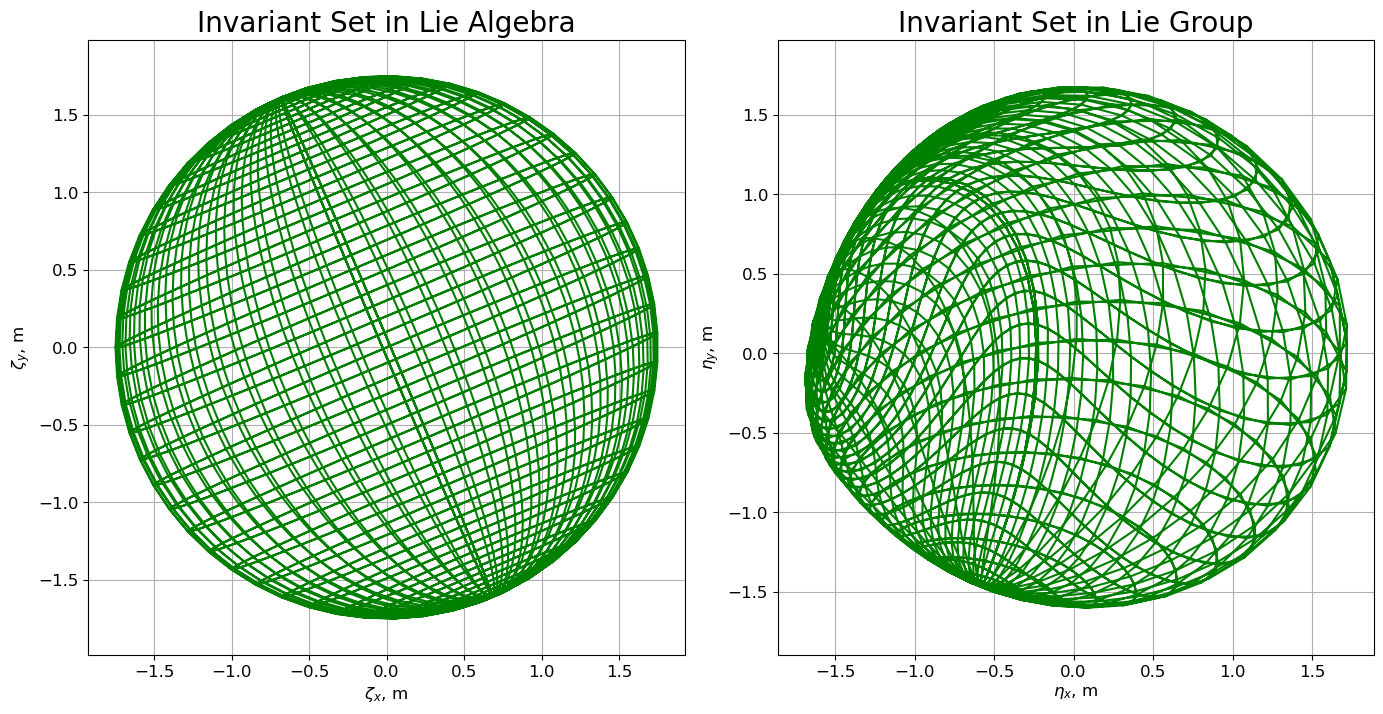

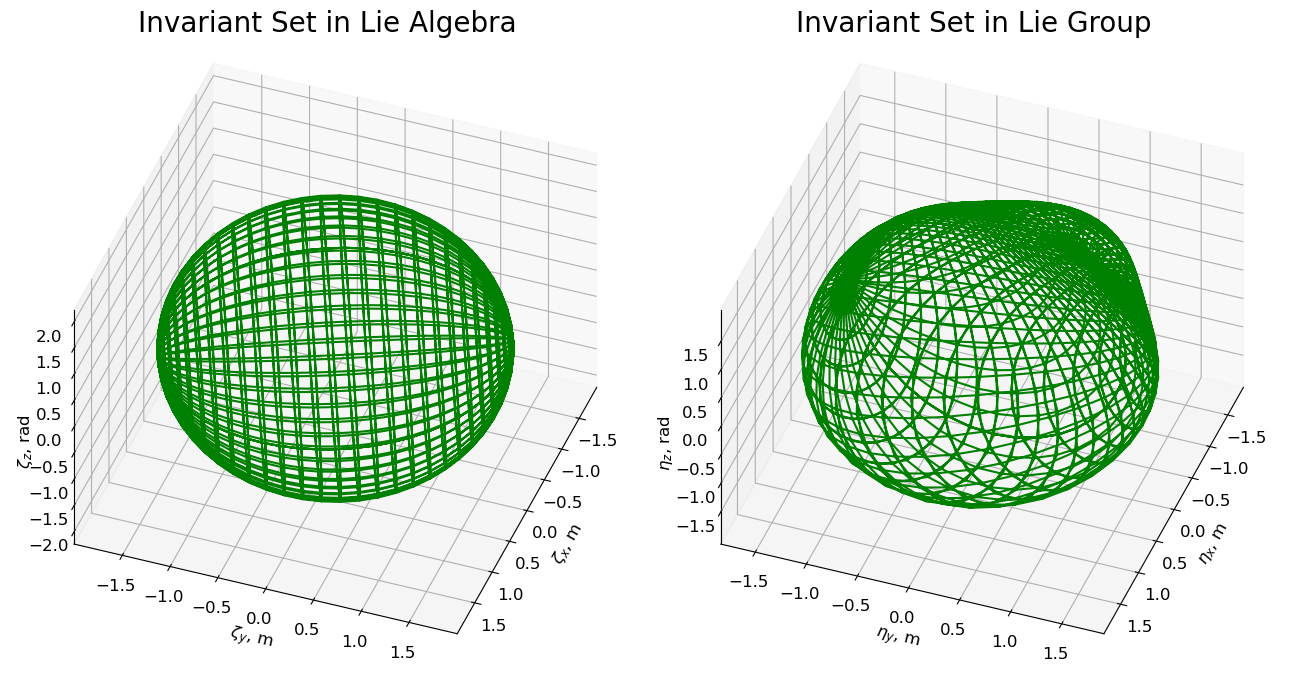

In [21]:
plt.figure(figsize=(14,7))
plt.rcParams.update({'font.size': 12})
ax1 = plt.subplot(121)
ax1.plot(points[0, :], points[1, :], 'g', label='with Dynamic Inversion')
# ax.plot(pointscl[0, :], pointscl[1, :], 'b', linewidth=0.5, label='without Dynamic Inversion')
ax1.set_xlabel('$\\zeta_x$, m')
ax1.set_ylabel('$\\zeta_y$, m')
# ax.plot(xopt.x,xopt.y,'ro')
plt.axis('equal')
plt.grid(True)
# plt.legend(loc=1)
ax2 = plt.subplot(122)
ax2.plot(inv_points[0, :-1], inv_points[1, :-1], 'g', label='with Dynamic Inversion')
# ax2.plot(inv_pointscl[0, :-1], inv_pointscl[1, :-1], 'b', linewidth=0.5, label='without Dynamic Inversion')
# ax2.plot(e[0],e[1],'ro')
ax2.set_xlabel('$\\eta_x$, m')
ax2.set_ylabel('$\\eta_y$, m')
plt.grid(True)
# plt.legend(loc=1)
plt.axis('equal')
plt.tight_layout()
ax1.set_title('Invariant Set in Lie Algebra', fontsize=20)
ax2.set_title('Invariant Set in Lie Group', fontsize=20)
# plt.savefig('figures/Invariant_l.eps', format='eps', bbox_inches='tight')

plt.figure(figsize=(14,7))
ax1 = plt.subplot(121, projection='3d', proj_type='ortho', elev=40, azim=20)
# ax.plot3D(e0[0], e0[1], e0[2], 'ro');
ax1.plot3D(points[0, :], points[1, :], points[2, :],'g', label='with Dynamic Inversion')
# ax.plot3D(pointscl[0, :], pointscl[1, :], pointscl[2, :],'b', linewidth=0.5, label='without Dynamic Inversion')
ax1.set_xlabel('$\\zeta_x$, m')
ax1.set_ylabel('$\\zeta_y$, m')
ax1.set_zlabel('$\\zeta_z$, rad', labelpad=1)
ax1.set_title('Invariant Set in Lie Algebra', fontsize=20)
# plt.subplots_adjust(left=9, right=10, top=0.5, bottom=0.08)
# plt.tight_layout()
plt.axis('auto')
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=1.0)
# plt.legend(loc=1)
ax2 = plt.subplot(122, projection='3d', proj_type='ortho', elev=40, azim=20)
# ax2.plot3D(e[0], e[1], e[2], 'ro');
ax2.plot3D(inv_points[0, :], inv_points[1, :], inv_points[2, :], 'g', label='with Dynamic Inversion')
# ax2.plot3D(inv_pointscl[0, :], inv_pointscl[1, :], inv_pointscl[2, :], 'b', linewidth=0.5, label='without Dynamic Inversion')
# ax2.plot3D(e[0], e[1], e[2], 'ro');
ax2.set_xlabel('$\\eta_x$, m')
ax2.set_ylabel('$\\eta_y$, m')
ax2.set_zlabel('$\\eta_z$, rad')
ax2.set_title('Invariant Set in Lie Group', fontsize=20)
plt.axis('auto')
plt.subplots_adjust(left=0.45, right=1, top=0.5, bottom=0.08)
# plt.legend(loc=1)
plt.tight_layout()
# plt.savefig('figures/Invariant3d_l.eps', format='eps', bbox_inches='tight')

In [22]:
# Calculate convex hull for flow pipes
n = 10 # number of flow pipes
flowpipes_traj, intervalhull_traj, nom_traj, t_vect = flowpipes(ref, n, ebeta, w1, omegabound, sol_LMI, 'xy')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


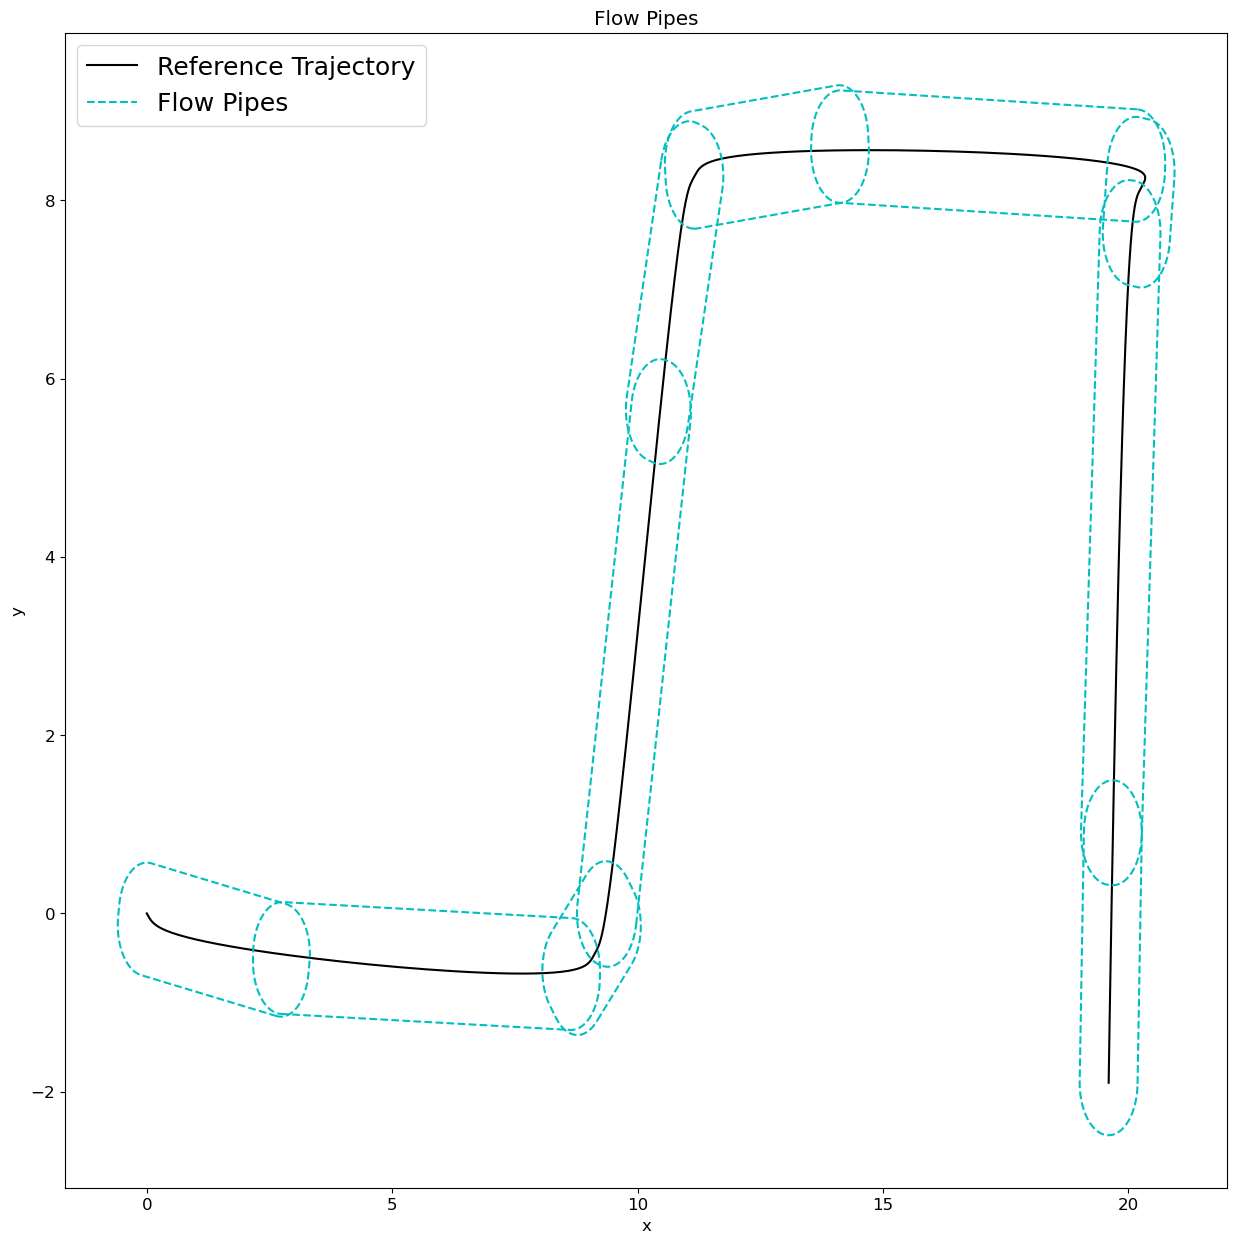

In [23]:
plot_flowpipes(nom_traj, flowpipes_traj, n, 'xy')

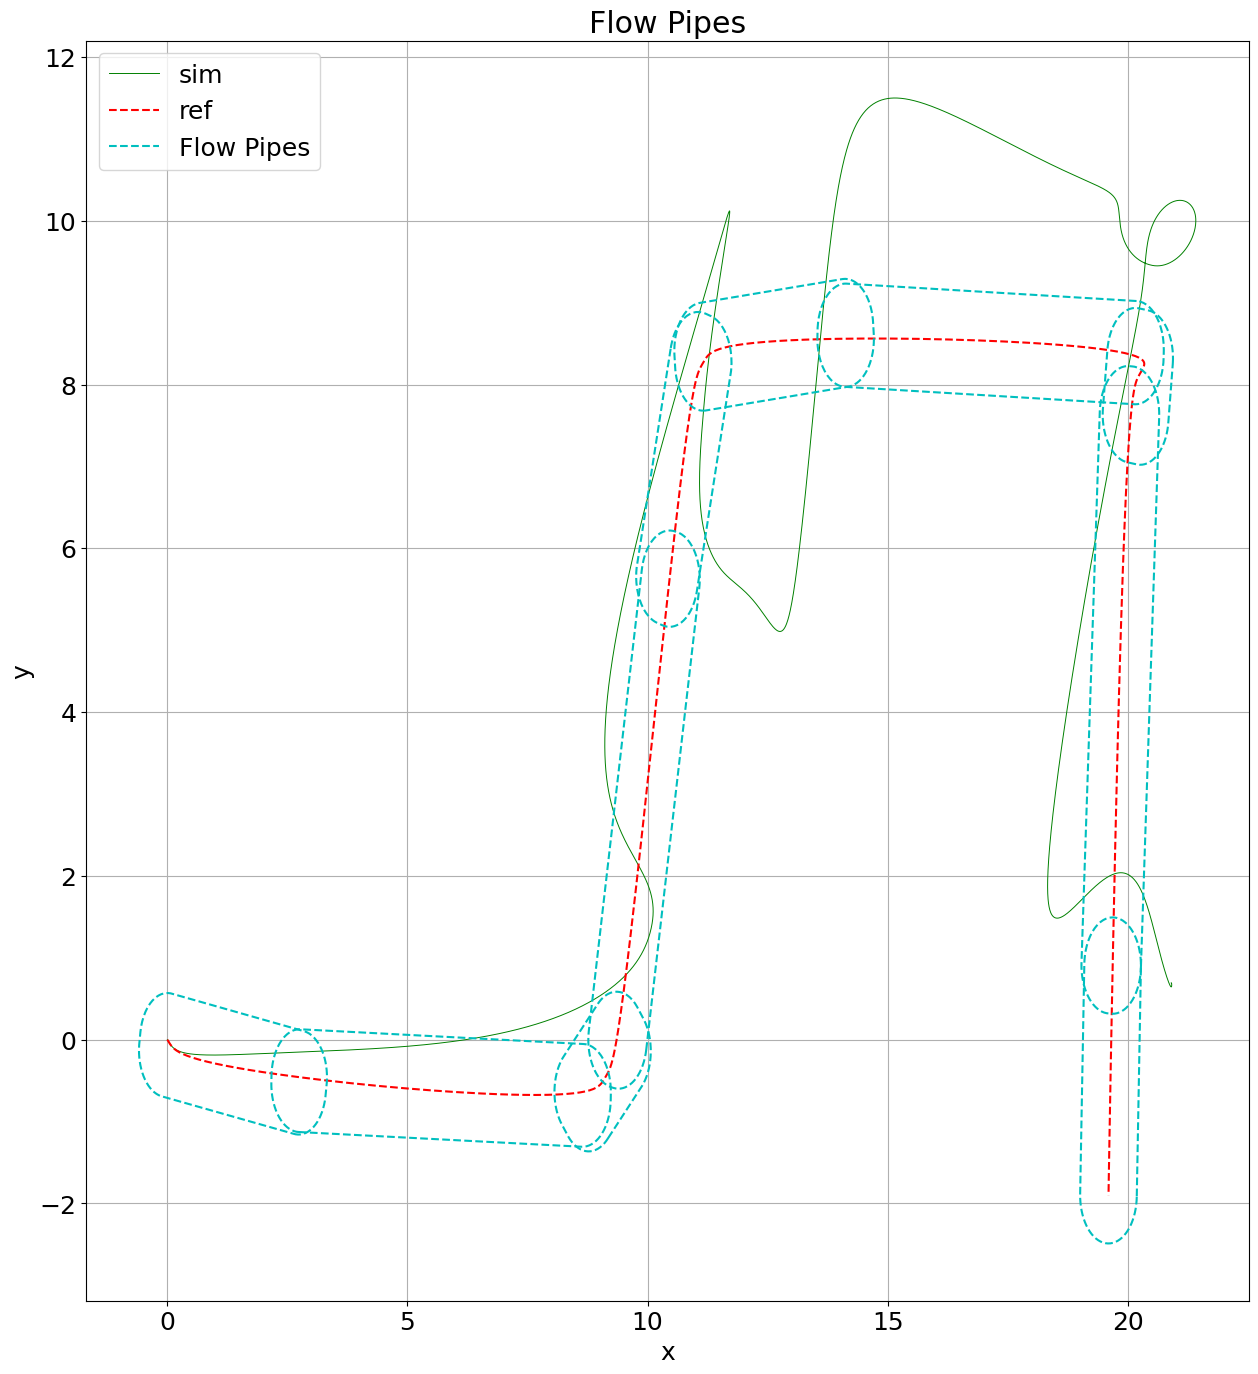

In [24]:
plot_sim(ref, w1, omegabound, flowpipes_traj, n, 'xy')